In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = '/content/drive/MyDrive/coco_dataset/coco dataset/images'

In [ ]:
import torch
from PIL import Image
import os

# Paths
images_path = '/content/drive/MyDrive/coco_dataset/coco dataset/Images'
save_path = '/content/drive/MyDrive/coco_dataset/processed'  # output folder

os.makedirs(os.path.join(save_path, 'rgb'), exist_ok=True)
os.makedirs(os.path.join(save_path, 'gray'), exist_ok=True)

# Get image files
image_files = [f for f in os.listdir(images_path) if f.lower().endswith(('.jpg','.png','.jpeg'))]
num_images = min(9000, len(image_files))  # use only first 9000 images

for i, img_file in enumerate(image_files[:num_images], 1):
    img_path = os.path.join(images_path, img_file)
    img = Image.open(img_path).convert('RGB')

    # Resize to 64x64
    img = img.resize((64,64))

    # Convert to tensors
    rgb_tensor = torch.tensor([[[pixel/255.0 for pixel in img.getpixel((x,y))] for x in range(64)] for y in range(64)]).permute(2,0,1)
    gray_tensor = torch.mean(rgb_tensor, dim=0, keepdim=True)  # [1,64,64]

    # Save tensors
    torch.save(rgb_tensor, os.path.join(save_path, 'rgb', img_file.split('.')[0]+'.pt'))
    torch.save(gray_tensor, os.path.join(save_path, 'gray', img_file.split('.')[0]+'.pt'))

    if i % 500 == 0:
        print(f'Processed {i}/{num_images} images')

print("✅ Preprocessing complete! Tensors saved for fast CPU training.")

Processed 500/9000 images
Processed 1000/9000 images
Processed 1500/9000 images
Processed 2000/9000 images
Processed 2500/9000 images
Processed 3000/9000 images
Processed 3500/9000 images
Processed 4000/9000 images
Processed 4500/9000 images
Processed 5000/9000 images
Processed 5500/9000 images
Processed 6000/9000 images
Processed 6500/9000 images
Processed 7000/9000 images
Processed 7500/9000 images
Processed 8000/9000 images
Processed 8500/9000 images
Processed 9000/9000 images
✅ Preprocessing complete! Tensors saved for fast CPU training.


In [ ]:
from torch.utils.data import Dataset, DataLoader
import os
import torch

class PreprocessedDataset(Dataset):
    def __init__(self, gray_folder, rgb_folder):
        self.gray_files = sorted(os.listdir(gray_folder))
        self.rgb_files = sorted(os.listdir(rgb_folder))
        self.gray_folder = gray_folder
        self.rgb_folder = rgb_folder

    def __len__(self):
        return len(self.gray_files)

    def __getitem__(self, idx):
        gray = torch.load(os.path.join(self.gray_folder, self.gray_files[idx]))
        rgb = torch.load(os.path.join(self.rgb_folder, self.rgb_files[idx]))
        return gray.float(), rgb.float()

dataset = PreprocessedDataset(
    '/content/drive/MyDrive/coco_dataset/processed/gray',
    '/content/drive/MyDrive/coco_dataset/processed/rgb'
)

dataloader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=2)
print("✅ Dataset loaded. Number of images:", len(dataset))

✅ Dataset loaded. Number of images: 9000


In [ ]:
import torch.nn as nn

class SimpleColorizationNet(nn.Module):
    def __init__(self):
        super(SimpleColorizationNet, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1), nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64, 3, 3, padding=1),
            nn.Sigmoid()  # output RGB [0,1]
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

model = SimpleColorizationNet()
print("✅ Model ready")

✅ Model ready


In [ ]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
num_epochs = 15

for epoch in range(num_epochs):
    running_loss = 0.0
    for gray_batch, rgb_batch in dataloader:
        # Forward
        outputs = model(gray_batch)
        loss = criterion(outputs, rgb_batch)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(dataloader):.4f}")

print("✅ Training complete!")

KeyboardInterrupt: 

In [ ]:
import torch

torch.save(
    model.state_dict(),
    '/content/drive/MyDrive/coco_dataset/colorization_model.pt'
)

print("Model saved successfully")

Model saved successfully


In [ ]:
import torch
import torch.nn as nn

# Define the same model again
class SimpleColorizationNet(nn.Module):
    def __init__(self):
        super(SimpleColorizationNet, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1), nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64, 3, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Create model
model = SimpleColorizationNet()

# Load saved weights
model.load_state_dict(
    torch.load('/content/drive/MyDrive/coco_dataset/colorization_model.pt')
)

model.eval()

print("Model loaded successfully")

Model loaded successfully


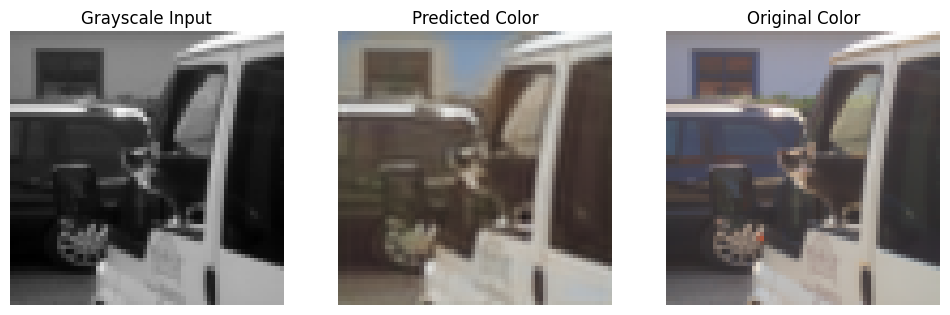

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

# Load one test image
img_path = '/content/drive/MyDrive/coco_dataset/coco dataset/Images'
import os

test_image = os.listdir(img_path)[0]
test_image_path = os.path.join(img_path, test_image)

# Transform
transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

img = Image.open(test_image_path).convert("RGB")
img_tensor = transform(img)

gray = transforms.functional.rgb_to_grayscale(img_tensor).unsqueeze(0)

# Predict
with torch.no_grad():
    output = model(gray)

predicted = output.squeeze().permute(1,2,0).numpy()
original = img_tensor.permute(1,2,0).numpy()
gray_img = gray.squeeze().numpy()

# Plot
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Grayscale Input")
plt.imshow(gray_img, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Predicted Color")
plt.imshow(predicted)
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Original Color")
plt.imshow(original)
plt.axis('off')

plt.show()

In [ ]:
print(img_tensor.shape)

torch.Size([3, 64, 64])


In [ ]:
import torch

print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

DATASET_PATH = "/content/drive/MyDrive/coco_dataset/coco dataset/Images"

MODEL_PATH = "/content/drive/MyDrive/coco_dataset/colorization_model.pt"

IMAGE_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-4

In [ ]:
import glob
import numpy as np
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as transforms

class ColorizationDataset(Dataset):

    def __init__(self, image_dir, size=128):

        self.image_paths = glob.glob(
            os.path.join(image_dir, "*.jpg")
        )

        self.size = size

        self.transform = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        img_path = self.image_paths[idx]

        img = Image.open(img_path).convert("RGB")

        img = self.transform(img)

        img_np = img.permute(1, 2, 0).numpy()

        import cv2
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)

        lab = lab.astype("float32") / 255.0

        L = lab[:, :, 0]
        ab = lab[:, :, 1:]

        L = torch.tensor(L).unsqueeze(0)
        ab = torch.tensor(ab).permute(2, 0, 1)

        return L, ab

In [ ]:
from torch.utils.data import DataLoader, Subset

dataset = ColorizationDataset(DATASET_PATH, size=IMAGE_SIZE)

print("Total images found:", len(dataset))

Total images found: 18834


In [ ]:
train_size = min(9000, len(dataset))

indices = list(range(train_size))

train_dataset = Subset(dataset, indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Training on images:", train_size)

Training on images: 9000


In [ ]:
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torch.load(MODEL_PATH, map_location=device)

model = model.to(device)

print("Model loaded successfully")

AttributeError: 'collections.OrderedDict' object has no attribute 'to'

In [ ]:
import torch.nn as nn

class UNetColorization(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = nn.Sequential(

            nn.Conv2d(1, 64, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(
                128,
                64,
                2,
                stride=2
            ),
            nn.ReLU(),

            nn.Conv2d(
                64,
                2,
                3,
                padding=1
            ),
            nn.Tanh()
        )

    def forward(self, x):

        x = self.encoder(x)

        x = self.decoder(x)

        return x

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = UNetColorization()

model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

model = model.to(device)

print("Model loaded successfully on", device)

RuntimeError: Error(s) in loading state_dict for UNetColorization:
	Missing key(s) in state_dict: "decoder.2.weight", "decoder.2.bias". 
	Unexpected key(s) in state_dict: "decoder.3.weight", "decoder.3.bias". 
	size mismatch for decoder.0.weight: copying a param with shape torch.Size([64, 128, 3, 3]) from checkpoint, the shape in current model is torch.Size([128, 64, 2, 2]).

In [ ]:
import torch

MODEL_PATH = "/content/drive/MyDrive/coco_dataset/colorization_model.pt"

checkpoint = torch.load(MODEL_PATH, map_location="cpu")

print(type(checkpoint))

if isinstance(checkpoint, dict):
    print("\nKeys in checkpoint:")
    print(checkpoint.keys())

    if "model_state_dict" in checkpoint:
        print("\nModel keys:")
        print(list(checkpoint["model_state_dict"].keys())[:20])

else:
    print("\nState dict keys:")
    print(list(checkpoint.keys())[:20])

<class 'collections.OrderedDict'>

Keys in checkpoint:
odict_keys(['encoder.0.weight', 'encoder.0.bias', 'encoder.2.weight', 'encoder.2.bias', 'decoder.0.weight', 'decoder.0.bias', 'decoder.3.weight', 'decoder.3.bias'])


In [ ]:
import torch.nn as nn

class UNetColorization(nn.Module):

    def __init__(self):

        super().__init__()

        # Encoder

        self.encoder = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU()
        )

        # Decoder — EXACT MATCH

        self.decoder = nn.Sequential(

            nn.Conv2d(
                in_channels=128,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.ReLU(),

            nn.Conv2d(
                in_channels=64,
                out_channels=3,
                kernel_size=3,
                padding=1
            )
        )

    def forward(self, x):

        x = self.encoder(x)

        x = self.decoder(x)

        return x

In [ ]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

MODEL_PATH = "/content/drive/MyDrive/coco_dataset/colorization_model.pt"

model = UNetColorization()

state_dict = torch.load(
    MODEL_PATH,
    map_location=device
)

model.load_state_dict(state_dict)

model = model.to(device)

print("Model loaded successfully")

Model loaded successfully


In [ ]:
print(next(model.parameters()).device)

cuda:0


In [ ]:
import torch.nn as nn

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [ ]:
EPOCHS = 10

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for gray, color in train_loader:

        gray = gray.to(device)
        color = color.to(device)

        optimizer.zero_grad()

        outputs = model(gray)

        loss = criterion(outputs, color)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f}"
    )

    # Save after every epoch
    torch.save(
        model.state_dict(),
        MODEL_PATH
    )

    print("Model saved")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([32, 2, 128, 128])) that is different to the input size (torch.Size([32, 3, 128, 128])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


RuntimeError: The size of tensor a (3) must match the size of tensor b (2) at non-singleton dimension 1

In [ ]:
import glob
import os
import torch
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as transforms

class ColorizationDataset(Dataset):

    def __init__(self, image_dir, size=128):

        self.image_paths = glob.glob(
            os.path.join(image_dir, "*.jpg")
        )

        self.transform = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor()
        ])

    def __len__(self):

        return len(self.image_paths)

    def __getitem__(self, idx):

        img_path = self.image_paths[idx]

        img = Image.open(img_path).convert("RGB")

        img = self.transform(img)

        # Create grayscale input

        gray = transforms.functional.rgb_to_grayscale(img)

        # Target is RGB image

        return gray, img

In [ ]:
from torch.utils.data import DataLoader, Subset

dataset = ColorizationDataset(
    DATASET_PATH,
    size=IMAGE_SIZE
)

train_size = min(9000, len(dataset))

indices = list(range(train_size))

train_dataset = Subset(dataset, indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Dataset ready")

Dataset ready


In [ ]:
gray, color = next(iter(train_loader))

print("Input shape:", gray.shape)
print("Target shape:", color.shape)

Input shape: torch.Size([32, 1, 128, 128])
Target shape: torch.Size([32, 3, 128, 128])


In [ ]:
for epoch in range(10):

    model.train()

    total_loss = 0

    for gray, color in train_loader:

        gray = gray.to(device)
        color = color.to(device)

        optimizer.zero_grad()

        outputs = model(gray)

        loss = criterion(outputs, color)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(
        f"Epoch {epoch+1} | Loss: {avg_loss:.4f}"
    )

    torch.save(
        model.state_dict(),
        MODEL_PATH
    )

KeyboardInterrupt: 

In [ ]:
print("Dataset size:", len(train_dataset))
print("Batches per epoch:", len(train_loader))
print("Batch size:", train_loader.batch_size)
print("Device:", device)

Dataset size: 9000
Batches per epoch: 282
Batch size: 32
Device: cuda


In [ ]:
import time

model.train()

start = time.time()

gray, color = next(iter(train_loader))

gray = gray.to(device)
color = color.to(device)

optimizer.zero_grad()

outputs = model(gray)

loss = criterion(outputs, color)

loss.backward()

optimizer.step()

end = time.time()

print("Time for ONE batch:", round(end - start, 2), "seconds")

Time for ONE batch: 9.31 seconds


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,      # try 2 first
    pin_memory=True
)

In [ ]:
gray, color = train_dataset[0]

print(gray.shape)
print(color.shape)

torch.Size([1, 128, 128])
torch.Size([3, 128, 128])


In [ ]:
gray = gray.to(device, non_blocking=True)
color = color.to(device, non_blocking=True)

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [ ]:
import time
import torch

num_epochs = 10

print("Starting training...")
print("Total batches per epoch:", len(train_loader))
print("Device:", device)

start_training_time = time.time()

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    epoch_start_time = time.time()

    for batch_idx, (gray, color) in enumerate(train_loader):

        batch_start_time = time.time()

        # Move to GPU (optimized)
        gray = gray.to(device, non_blocking=True)
        color = color.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(gray)

        loss = criterion(outputs, color)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        # Calculate batch time
        batch_time = time.time() - batch_start_time

        # Estimate remaining time
        batches_left = len(train_loader) - (batch_idx + 1)
        eta_seconds = batches_left * batch_time

        eta_minutes = eta_seconds / 60

        # Show progress every 20 batches
        if (batch_idx + 1) % 20 == 0:

            print(
                f"Epoch [{epoch+1}/{num_epochs}] "
                f"Batch [{batch_idx+1}/{len(train_loader)}] "
                f"Loss: {loss.item():.4f} "
                f"ETA: {eta_minutes:.1f} min"
            )

    # Epoch finished
    epoch_time = time.time() - epoch_start_time

    avg_loss = running_loss / len(train_loader)

    print("\n----------------------------------------")
    print(f"Epoch {epoch+1} completed")
    print(f"Average Loss: {avg_loss:.4f}")
    print(f"Epoch Time: {epoch_time/60:.2f} minutes")
    print("----------------------------------------\n")

    # Save model checkpoint
    torch.save(model.state_dict(), "colorization_model.pth")

# Training finished
total_time = time.time() - start_training_time

print("Training finished!")
print(f"Total Training Time: {total_time/60:.2f} minutes")

Starting training...
Total batches per epoch: 282
Device: cuda
Epoch [1/10] Batch [20/282] Loss: 0.0213 ETA: 0.7 min
Epoch [1/10] Batch [40/282] Loss: 0.0224 ETA: 0.6 min
Epoch [1/10] Batch [60/282] Loss: 0.0171 ETA: 0.6 min
Epoch [1/10] Batch [80/282] Loss: 0.0139 ETA: 0.5 min
Epoch [1/10] Batch [100/282] Loss: 0.0170 ETA: 0.4 min
Epoch [1/10] Batch [120/282] Loss: 0.0144 ETA: 0.4 min
Epoch [1/10] Batch [140/282] Loss: 0.0146 ETA: 0.3 min
Epoch [1/10] Batch [160/282] Loss: 0.0152 ETA: 0.2 min
Epoch [1/10] Batch [180/282] Loss: 0.0135 ETA: 0.2 min
Epoch [1/10] Batch [200/282] Loss: 0.0105 ETA: 0.2 min
Epoch [1/10] Batch [220/282] Loss: 0.0128 ETA: 0.1 min
Epoch [1/10] Batch [240/282] Loss: 0.0125 ETA: 0.1 min
Epoch [1/10] Batch [260/282] Loss: 0.0114 ETA: 0.1 min
Epoch [1/10] Batch [280/282] Loss: 0.0077 ETA: 0.0 min

----------------------------------------
Epoch 1 completed
Average Loss: 0.0149
Epoch Time: 11.41 minutes
----------------------------------------

Epoch [2/10] Batch [20

In [ ]:
torch.save(model.state_dict(), "colorization_model_final.pth")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
import os

print(os.listdir())

['.config', 'colorization_model.pth', 'colorization_model_final.pth', 'drive', 'sample_data']


In [ ]:
torch.save(model.state_dict(), "colorization_model_backup.pth")

print("Backup model saved!")

Backup model saved!


In [ ]:
from google.colab import files

files.download("colorization_model_final.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(os.path.exists("colorization_model_final.pth"))

True


In [ ]:
model.load_state_dict(torch.load("colorization_model_final.pth"))
model = model.to(device)

model.eval()

print("Model loaded for inference")

Model loaded for inference


In [ ]:
import matplotlib.pyplot as plt
import torch

model.eval()

gray, color = test_dataset[25]

with torch.no_grad():
    output = model(gray.unsqueeze(0).to(device))

pred = output.squeeze(0).cpu()

print("Prediction generated")

NameError: name 'test_dataset' is not defined

In [ ]:
from torch.utils.data import random_split

# Define split sizes
train_size = int(0.8 * len(train_dataset))
test_size = len(train_dataset) - train_size

train_dataset, test_dataset = random_split(
    train_dataset,
    [train_size, test_size]
)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Train size: 7200
Test size: 1800


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
import matplotlib.pyplot as plt
import torch

model.eval()

gray, color = test_dataset[25]

with torch.no_grad():
    output = model(gray.unsqueeze(0).to(device))

pred = output.squeeze(0).cpu()

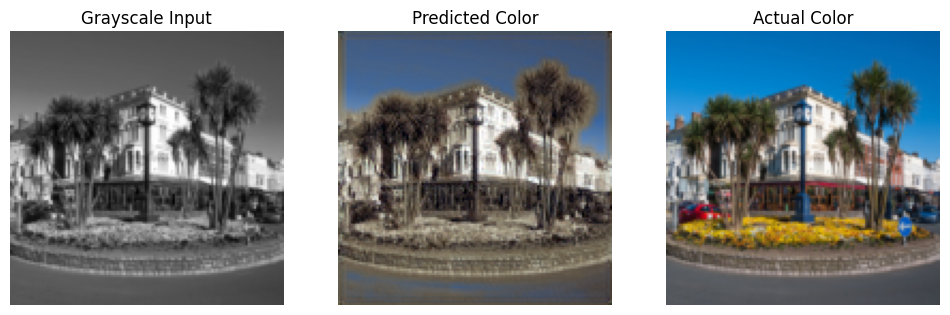

In [ ]:
plt.figure(figsize=(12,4))

# Grayscale
plt.subplot(1,3,1)
plt.title("Grayscale Input")
plt.imshow(gray.permute(1,2,0), cmap="gray")
plt.axis("off")

# Prediction
plt.subplot(1,3,2)
plt.title("Predicted Color")
plt.imshow(pred.permute(1,2,0))
plt.axis("off")

# Ground Truth
plt.subplot(1,3,3)
plt.title("Actual Color")
plt.imshow(color.permute(1,2,0))
plt.axis("off")

plt.show()

In [ ]:
plt.imsave(
    "colorization_result.png",
    pred.permute(1,2,0)
)

print("Result saved!")

Result saved!


In [ ]:
import os

print(os.listdir())

['.config', 'colorization_model.pth', 'colorization_result.png', 'colorization_model_backup.pth', 'colorization_model_final.pth', 'drive', 'sample_data']


In [ ]:
from google.colab import files

files.download("colorization_model_final.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
import os
print(os.listdir())

['.config', 'sample_data']
